In [1]:
## 1. Import Libraries and Set Reproducibility

import os
import random
import zipfile
import shutil

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image

RANDOM_SEED = 42
IMAGE_SIZE = (224, 224)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Random seed set to:", RANDOM_SEED)

Random seed set to: 42


In [2]:
## 2. Mount Google Drive and Load Shenzhen Predictions

from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = "/content/drive/MyDrive/Master_datascience_thesis"

external_output_dir = os.path.join(PROJECT_ROOT,"outputs","external_validation")

shenzhen_predictions = pd.read_csv(os.path.join(external_output_dir,"shenzhen_predictions.csv"))

print("Shenzhen prediction rows:", len(shenzhen_predictions))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shenzhen prediction rows: 662


In [3]:
## 3. Load Saved TBX11K Validation Scores

deep_learning_dir = os.path.join(PROJECT_ROOT,"outputs","deep_learning")

finetuned_scores_df = pd.read_csv(os.path.join(deep_learning_dir,"deep_learning_finetuned_validation_scores.csv"))

print("Rows loaded:", len(finetuned_scores_df))
print("Columns:", finetuned_scores_df.columns.tolist())

display(finetuned_scores_df.head())

Rows loaded: 1794
Columns: ['path', 'label', 'ResNet50_score', 'MobileNetV2_score']


,path,label,ResNet50_score,MobileNetV2_score
0,sick/s0008.png,0,0.000042,0.000216
1,sick/s1596.png,0,0.137693,0.060533
2,sick/s2013.png,0,0.001649,0.002398
3,health/h1668.png,0,0.005818,0.057680
4,sick/s3863.png,0,0.004497,0.022454


In [4]:
## 4. Select TBX11K Grad-CAM++ Cases

RESNET50_THRESHOLD = 0.698488

tbx_predictions = finetuned_scores_df[["path", "label", "ResNet50_score"]].copy()

tbx_predictions["prediction"] = (tbx_predictions["ResNet50_score"] >= RESNET50_THRESHOLD).astype(int)

tbx_predictions["outcome"] = [
    "TP" if y == 1 and p == 1 else
    "TN" if y == 0 and p == 0 else
    "FP" if y == 0 and p == 1 else
    "FN"
    for y, p in zip(
        tbx_predictions["label"],
        tbx_predictions["prediction"]
    )
]

tbx_gradcam_cases = (tbx_predictions.groupby("outcome", group_keys=False).sample(2, random_state=RANDOM_SEED).reset_index(drop=True))

display(tbx_gradcam_cases)

,path,label,ResNet50_score,prediction,outcome
0,tb/tb0995.png,1,0.235502,0,FN
1,tb/tb0326.png,1,0.008578,0,FN
2,sick/s2674.png,0,0.809942,1,FP
3,sick/s3649.png,0,0.977291,1,FP
4,sick/s3128.png,0,0.001668,0,TN
5,sick/s3847.png,0,0.113373,0,TN
6,tb/tb0667.png,1,0.823445,1,TP
7,tb/tb0634.png,1,0.997594,1,TP


In [5]:
## 5. Select Shenzhen Grad-CAM++ Cases

shenzhen_predictions["outcome"] = [
    "TP" if y == 1 and p == 1 else
    "TN" if y == 0 and p == 0 else
    "FP" if y == 0 and p == 1 else
    "FN"
    for y, p in zip(
        shenzhen_predictions["label"],
        shenzhen_predictions["resnet50_prediction"]
    )
]

shenzhen_gradcam_cases = (
    shenzhen_predictions
    .groupby("outcome", group_keys=False)
    .sample(2, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

display(
    shenzhen_gradcam_cases[
        ["path", "label", "resnet50_score",
         "resnet50_prediction", "outcome"]
    ]
)

,path,label,resnet50_score,resnet50_prediction,outcome
0,/content/drive/MyDrive/Master_datascience_thes...,1,0.003349,0,FN
1,/content/drive/MyDrive/Master_datascience_thes...,1,0.050521,0,FN
2,/content/drive/MyDrive/Master_datascience_thes...,0,0.772206,1,FP
3,/content/drive/MyDrive/Master_datascience_thes...,0,0.897804,1,FP
4,/content/drive/MyDrive/Master_datascience_thes...,0,0.335613,0,TN
5,/content/drive/MyDrive/Master_datascience_thes...,0,0.058421,0,TN
6,/content/drive/MyDrive/Master_datascience_thes...,1,0.939768,1,TP
7,/content/drive/MyDrive/Master_datascience_thes...,1,0.883580,1,TP


In [6]:
## 6. Load Fine-Tuned ResNet50

resnet50_model = tf.keras.models.load_model(
    os.path.join(
        PROJECT_ROOT,
        "outputs",
        "deep_learning",
        "best_resnet50_finetuned.keras"
    )
)

print("Fine-tuned ResNet50 loaded")

Fine-tuned ResNet50 loaded


In [7]:
## 7. Set Grad-CAM++ Target Layer

resnet_base = [
    layer for layer in resnet50_model.layers
    if "resnet" in layer.name.lower()
][0]

last_conv_layer = resnet_base.get_layer("conv5_block3_out")

print("Target layer:", last_conv_layer.name)

Target layer: conv5_block3_out


In [8]:
## 8. Define Grad-CAM++ Function

feature_model = tf.keras.Model(
    resnet_base.input,
    last_conv_layer.output
)

gap_layer = resnet50_model.layers[-2]
classifier = resnet50_model.layers[-1]

def gradcam_plus_plus(image_path, predicted_class):

    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (224, 224))
    image = tf.expand_dims(image, 0)
    image = tf.keras.applications.resnet50.preprocess_input(image)

    with tf.GradientTape() as tape3:
        with tf.GradientTape() as tape2:
            with tf.GradientTape() as tape1:

                conv = feature_model(image, training=False)

                tape1.watch(conv)
                tape2.watch(conv)
                tape3.watch(conv)

                probability = classifier(gap_layer(conv))[:, 0]

                if predicted_class == 1:
                    score = probability
                else:
                    score = 1 - probability

            grad1 = tape1.gradient(score, conv)

        grad2 = tape2.gradient(grad1, conv)

    grad3 = tape3.gradient(grad2, conv)

    alpha_num = grad2

    alpha_den = (
        2 * grad2 +
        grad3 * tf.reduce_sum(
            conv,
            axis=(1, 2),
            keepdims=True
        )
    )

    alpha = alpha_num / (
        alpha_den + tf.keras.backend.epsilon()
    )

    weights = tf.reduce_sum(
        alpha * tf.nn.relu(grad1),
        axis=(1, 2)
    )

    heatmap = tf.reduce_sum(
        weights[:, None, None, :] * conv,
        axis=-1
    )[0]

    heatmap = tf.nn.relu(heatmap)
    heatmap /= (
        tf.reduce_max(heatmap) +
        tf.keras.backend.epsilon()
    )

    return heatmap.numpy()

In [9]:
## 9. Prepare Selected TBX11K Images


zip_path = os.path.join(
    PROJECT_ROOT,
    "data",
    "TBX11K.zip"
)

tbx_temp_dir = "/content/tbx_gradcam"
os.makedirs(tbx_temp_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_file:
    for i, row in tbx_gradcam_cases.iterrows():

        member = f"TBX11K/imgs/{row['path']}"
        output_path = os.path.join(
            tbx_temp_dir,
            os.path.basename(row["path"])
        )

        with open(output_path, "wb") as f:
            f.write(zip_file.read(member))

        tbx_gradcam_cases.loc[i, "image_path"] = output_path

print("TBX11K images prepared:", len(tbx_gradcam_cases))

TBX11K images prepared: 8


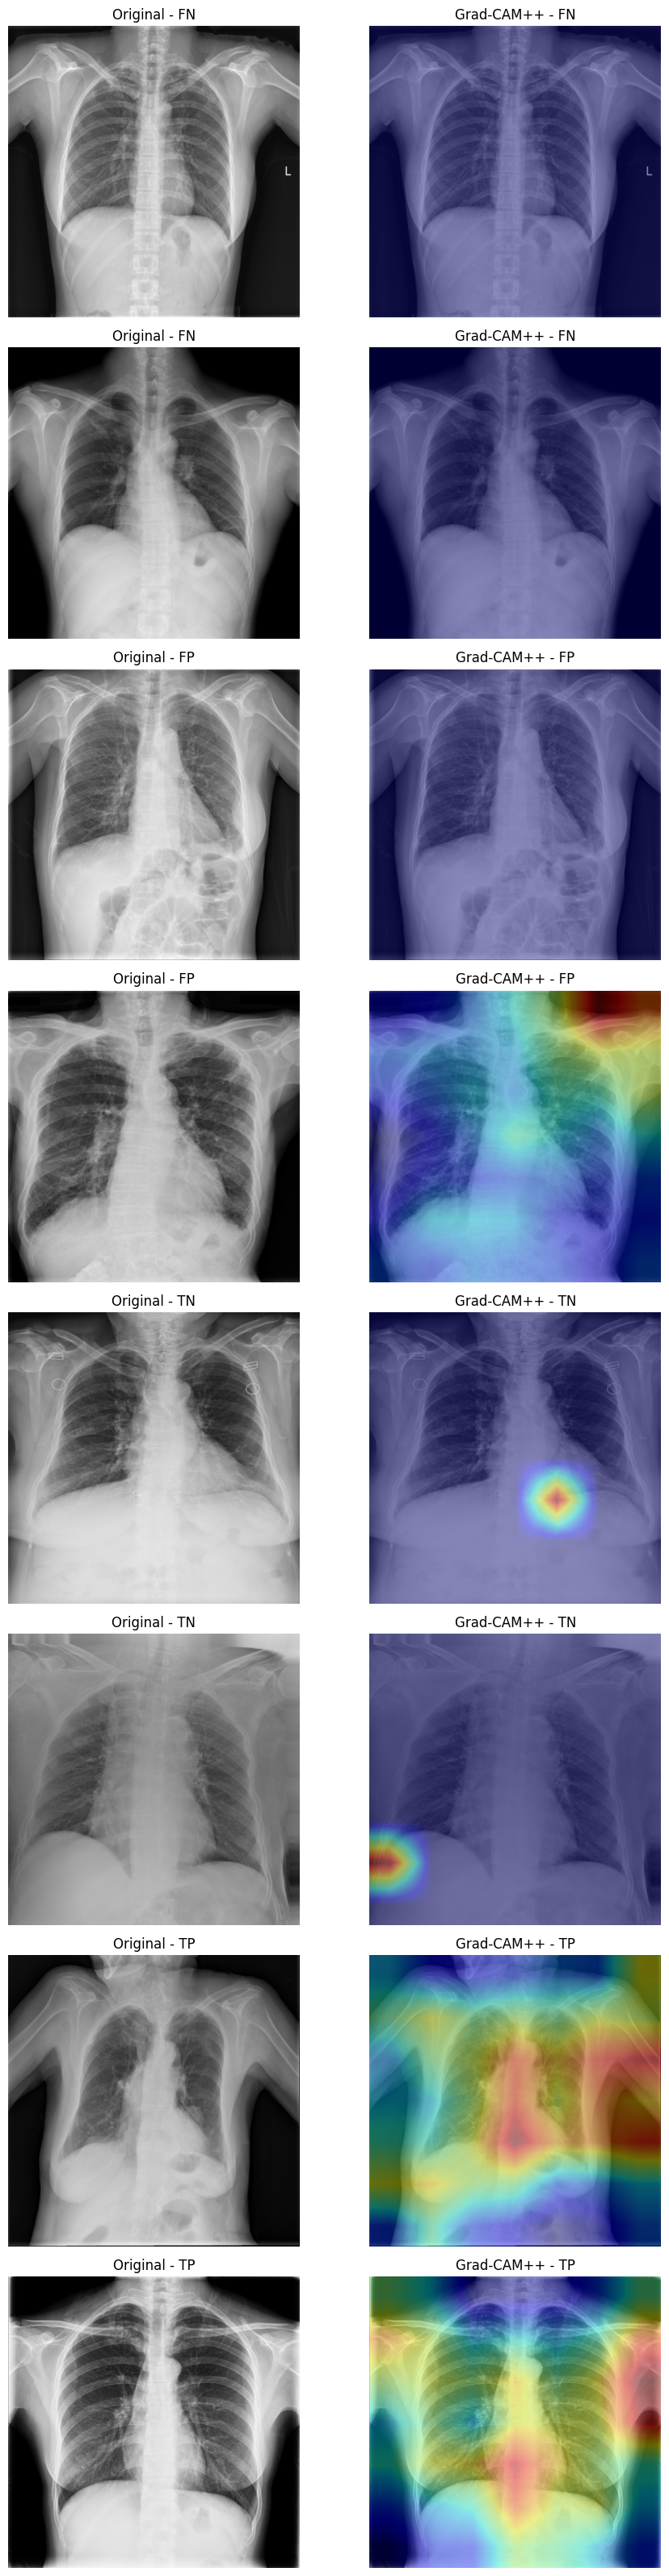

Saved: /content/drive/MyDrive/Master_datascience_thesis/outputs/gradcam/tbx11k_gradcam_cases.png


In [10]:
## 10. Save TBX11K Grad-CAM++ Results

gradcam_output_dir = os.path.join(PROJECT_ROOT,"outputs","gradcam")

os.makedirs(gradcam_output_dir, exist_ok=True)

fig, axes = plt.subplots(8, 2, figsize=(10, 32))

for i, (_, row) in enumerate(tbx_gradcam_cases.iterrows()):

    image = tf.io.decode_png(
        tf.io.read_file(row["image_path"]),
        channels=3
    )

    heatmap = gradcam_plus_plus(
        row["image_path"],
        int(row["prediction"])
    )

    heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        image.shape[:2]
    ).numpy().squeeze()

    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f"Original - {row['outcome']}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(image)
    axes[i, 1].imshow(
        heatmap,
        cmap="jet",
        alpha=0.4
    )
    axes[i, 1].set_title(f"Grad-CAM++ - {row['outcome']}")
    axes[i, 1].axis("off")

plt.tight_layout()

tbx_gradcam_path = os.path.join(
    gradcam_output_dir,
    "tbx11k_gradcam_cases.png"
)

plt.savefig(
    tbx_gradcam_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", tbx_gradcam_path)

In [11]:
## 11. Prepare Selected Shenzhen Images

import shutil

shenzhen_temp_dir = "/content/shenzhen_gradcam"
os.makedirs(shenzhen_temp_dir, exist_ok=True)

for i, row in shenzhen_gradcam_cases.iterrows():

    output_path = os.path.join(
        shenzhen_temp_dir,
        os.path.basename(row["path"])
    )

    shutil.copy(row["path"], output_path)

    shenzhen_gradcam_cases.loc[i, "image_path"] = output_path

print("Shenzhen images prepared:", len(shenzhen_gradcam_cases))

Shenzhen images prepared: 8


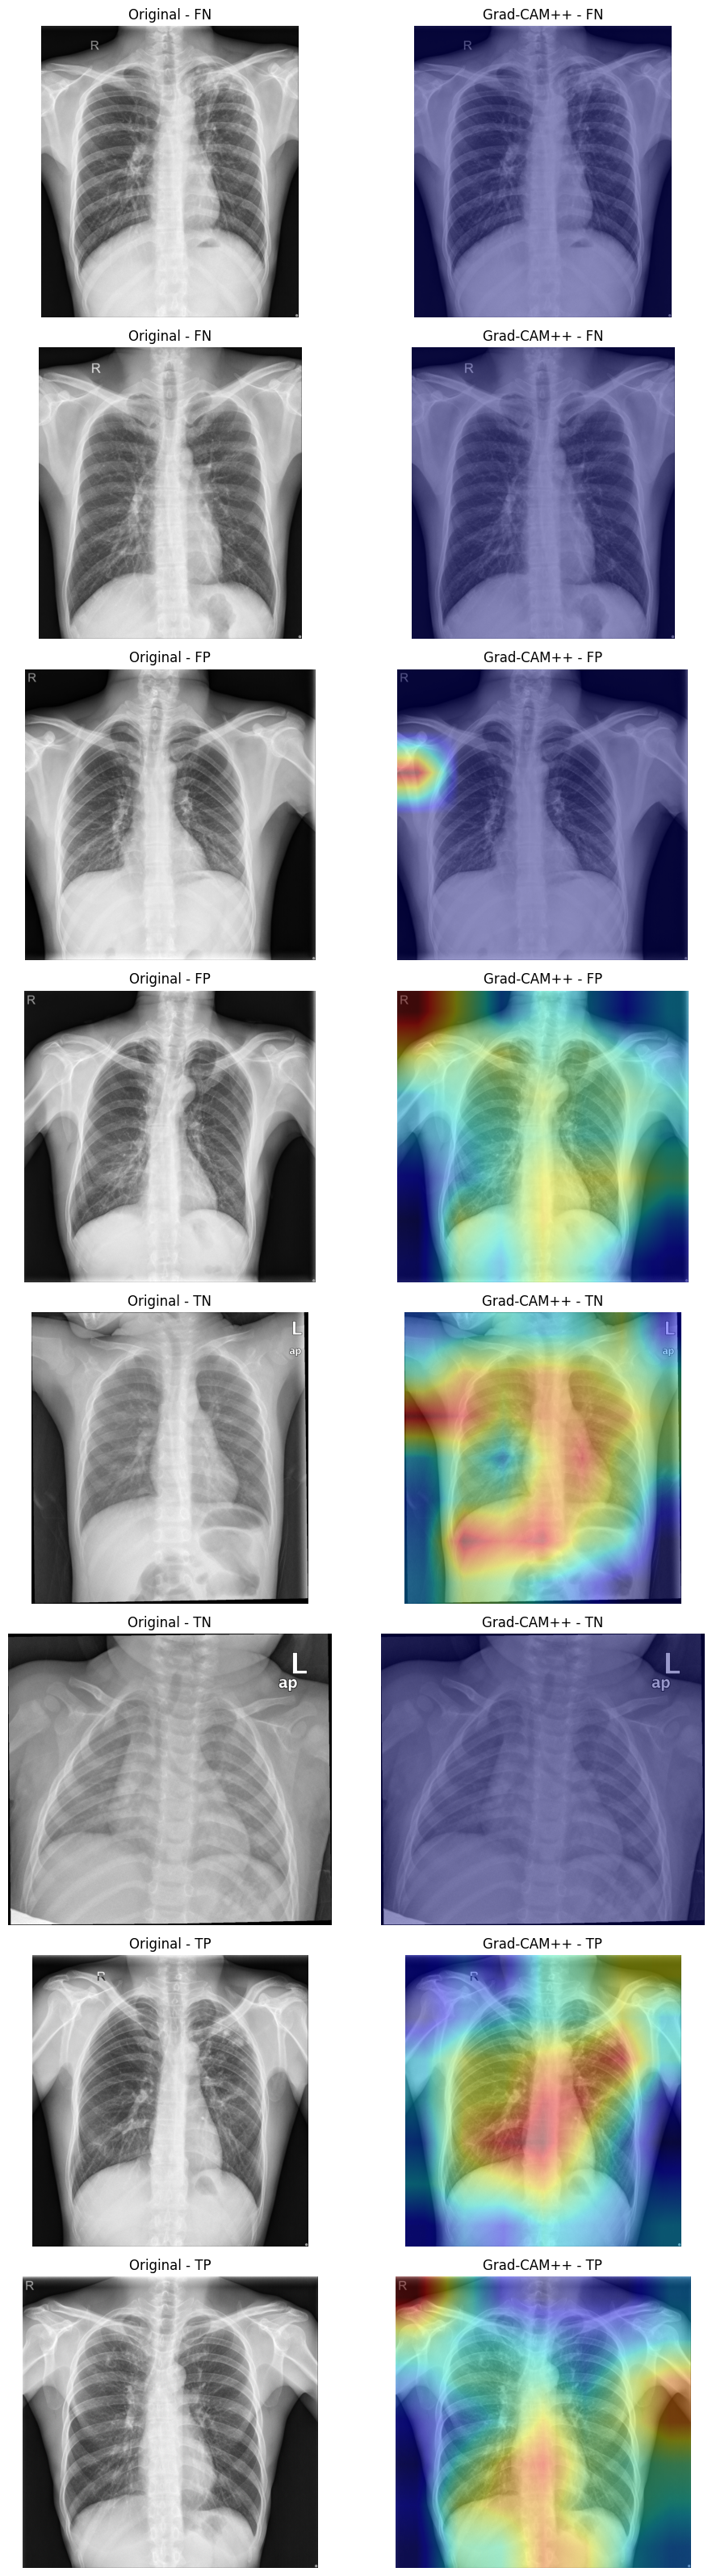

Saved: /content/drive/MyDrive/Master_datascience_thesis/outputs/gradcam/shenzhen_gradcam_cases.png


In [12]:
## 12. Save Shenzhen Grad-CAM++ Results

fig, axes = plt.subplots(8, 2, figsize=(10, 32))

for i, (_, row) in enumerate(shenzhen_gradcam_cases.iterrows()):

    image = tf.io.decode_png(
        tf.io.read_file(row["image_path"]),
        channels=3
    )

    heatmap = gradcam_plus_plus(
        row["image_path"],
        int(row["resnet50_prediction"])
    )

    heatmap = tf.image.resize(
        heatmap[..., np.newaxis],
        image.shape[:2]
    ).numpy().squeeze()

    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f"Original - {row['outcome']}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(image)
    axes[i, 1].imshow(
        heatmap,
        cmap="jet",
        alpha=0.4
    )
    axes[i, 1].set_title(f"Grad-CAM++ - {row['outcome']}")
    axes[i, 1].axis("off")

plt.tight_layout()

shenzhen_gradcam_path = os.path.join(
    gradcam_output_dir,
    "shenzhen_gradcam_cases.png"
)

plt.savefig(
    shenzhen_gradcam_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", shenzhen_gradcam_path)